## 1. Prepare Data & Create Profile

### Import libraries and load datasets

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 100)

AccidentDf = pd.read_csv("accident.csv", low_memory=False, encoding='unicode_escape')
VehicleDf = pd.read_csv("vehicle.csv", low_memory=False, encoding='unicode_escape')

print("Files loaded successfully")
print("Accident shape:", AccidentDf.shape)
print("Vehicle shape:", VehicleDf.shape)

Files loaded successfully
Accident shape: (200352, 23)
Vehicle shape: (365470, 37)


### Inspect datasets

In [7]:
AccidentDf.info()

VehicleDf.info()

print("\nAccident Sample Entry")
display(AccidentDf.head(1))

print("\nVehicle Sample Entry")
display(VehicleDf.head(1))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200352 entries, 0 to 200351
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   ACCIDENT_NO         200352 non-null  object
 1   ACCIDENT_DATE       200352 non-null  object
 2   ACCIDENT_TIME       200352 non-null  object
 3   ACCIDENT_TYPE       200352 non-null  int64 
 4   ACCIDENT_TYPE_DESC  200352 non-null  object
 5   DAY_OF_WEEK         200352 non-null  int64 
 6   DAY_WEEK_DESC       200352 non-null  object
 7   DCA_CODE            200352 non-null  int64 
 8   DCA_DESC            200352 non-null  object
 9   LIGHT_CONDITION     200352 non-null  int64 
 10  NODE_ID             200352 non-null  int64 
 11  NO_OF_VEHICLES      200352 non-null  int64 
 12  NO_PERSONS_KILLED   200352 non-null  int64 
 13  NO_PERSONS_INJ_2    200352 non-null  int64 
 14  NO_PERSONS_INJ_3    200352 non-null  int64 
 15  NO_PERSONS_NOT_INJ  200352 non-null  int64 
 16  NO

,ACCIDENT_NO,ACCIDENT_DATE,ACCIDENT_TIME,ACCIDENT_TYPE,ACCIDENT_TYPE_DESC,DAY_OF_WEEK,DAY_WEEK_DESC,DCA_CODE,DCA_DESC,LIGHT_CONDITION,NODE_ID,NO_OF_VEHICLES,NO_PERSONS_KILLED,NO_PERSONS_INJ_2,NO_PERSONS_INJ_3,NO_PERSONS_NOT_INJ,NO_PERSONS,POLICE_ATTEND,ROAD_GEOMETRY,ROAD_GEOMETRY_DESC,SEVERITY,SPEED_ZONE,RMA
0,T20120002354,2012-01-31,10:35:00,1,Collision with vehicle,3,Tuesday,121,RIGHT THROUGH,1,277152,2,0,1,1,1,3,1,1,Cross intersection,2,60,Arterial Highway



Vehicle Sample Entry


,ACCIDENT_NO,VEHICLE_ID,VEHICLE_YEAR_MANUF,VEHICLE_DCA_CODE,INITIAL_DIRECTION,ROAD_SURFACE_TYPE,ROAD_SURFACE_TYPE_DESC,REG_STATE,VEHICLE_BODY_STYLE,VEHICLE_MAKE,VEHICLE_MODEL,VEHICLE_POWER,VEHICLE_TYPE,VEHICLE_TYPE_DESC,VEHICLE_WEIGHT,CONSTRUCTION_TYPE,FUEL_TYPE,NO_OF_WHEELS,NO_OF_CYLINDERS,SEATING_CAPACITY,TARE_WEIGHT,TOTAL_NO_OCCUPANTS,CARRY_CAPACITY,CUBIC_CAPACITY,FINAL_DIRECTION,DRIVER_INTENT,VEHICLE_MOVEMENT,TRAILER_TYPE,VEHICLE_COLOUR_1,VEHICLE_COLOUR_2,CAUGHT_FIRE,INITIAL_IMPACT,LAMPS,LEVEL_OF_DAMAGE,TOWED_AWAY_FLAG,TRAFFIC_CONTROL,TRAFFIC_CONTROL_DESC
0,T20120000009,A,1996.0,1.0,E,1.0,Paved,V,SEDAN,HOLDEN,ACCLAI,NaN,1,Car,NaN,R,P,4.0,6.0,5.0,1350.0,2.0,NaN,NaN,E,1.0,18.0,H,WHI,ZZ,2.0,1,1.0,5,1.0,0.0,No control


### Structure and data types

#### Dataset structure


In [8]:
def structure_profile(df, dataset_name, filename):
    file_size_mb = Path(filename).stat().st_size / (1024 ** 2)

    print(f"{dataset_name} dataset")
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]:,}")
    print(f"File size: {file_size_mb:.2f} MB")
    print(
        f"Memory usage: "
        f"{df.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB"
    )

    profile = pd.DataFrame({
        "Column": df.columns,
        "Python data type": df.dtypes.astype(str).values,
        "Non-null values": df.notna().sum().values,
        "Missing values": df.isna().sum().values,
        "Unique values": df.nunique(dropna=True).values
    })

    profile["Missing percentage"] = (
        profile["Missing values"] / len(df) * 100
    ).round(2)

    return profile


accident_structure = structure_profile(
    AccidentDf,
    "Accident",
    "accident.csv"
)

display(accident_structure)

vehicle_structure = structure_profile(
    VehicleDf,
    "Vehicle",
    "vehicle.csv"
)

display(vehicle_structure)

Accident dataset
Rows: 200,352
Columns: 23
File size: 32.78 MB
Memory usage: 133.55 MB


,Column,Python data type,Non-null values,Missing values,Unique values,Missing percentage
0,ACCIDENT_NO,object,200352,0,200352,0.00
1,ACCIDENT_DATE,object,200352,0,5114,0.00
2,ACCIDENT_TIME,object,200352,0,1440,0.00
3,ACCIDENT_TYPE,int64,200352,0,9,0.00
4,ACCIDENT_TYPE_DESC,object,200352,0,9,0.00
5,DAY_OF_WEEK,int64,200352,0,8,0.00
6,DAY_WEEK_DESC,object,200352,0,7,0.00
7,DCA_CODE,int64,200352,0,81,0.00
8,DCA_DESC,object,200352,0,81,0.00
9,LIGHT_CONDITION,int64,200352,0,7,0.00


Vehicle dataset
Rows: 365,470
Columns: 37
File size: 44.47 MB
Memory usage: 410.90 MB


,Column,Python data type,Non-null values,Missing values,Unique values,Missing percentage
0,ACCIDENT_NO,object,365470,0,200343,0.00
1,VEHICLE_ID,object,365470,0,21,0.00
2,VEHICLE_YEAR_MANUF,float64,358519,6951,109,1.90
3,VEHICLE_DCA_CODE,float64,364538,932,4,0.26
4,INITIAL_DIRECTION,object,365469,1,9,0.00
5,ROAD_SURFACE_TYPE,float64,365469,1,4,0.00
6,ROAD_SURFACE_TYPE_DESC,object,365469,1,4,0.00
7,REG_STATE,object,343025,22445,11,6.14
8,VEHICLE_BODY_STYLE,object,337119,28351,118,7.76
9,VEHICLE_MAKE,object,345364,20106,687,5.50


#### Cell 4 — Duplicate rows

In [9]:
def duplicate_profile(df, dataset_name):
    exact_duplicates = df.duplicated().sum()
    duplicate_rows_including_first = df.duplicated(
        keep=False
    ).sum()

    print(f"{dataset_name}:")
    print(f"Exact duplicate records: {exact_duplicates:,}")
    print(
        "All rows belonging to duplicate groups:",
        f"{duplicate_rows_including_first:,}"
    )
    print(
        "Exact duplicate percentage:",
        f"{exact_duplicates / len(df) * 100:.2f}%"
    )

    duplicates = df[df.duplicated(keep=False)]

    return duplicates


accident_duplicates = duplicate_profile(
    AccidentDf,
    "Accident data"
)

vehicle_duplicates = duplicate_profile(
    VehicleDf,
    "Vehicle data"
)

display(accident_duplicates.head(20))
display(vehicle_duplicates.head(20))

Accident data:
Exact duplicate records: 0
All rows belonging to duplicate groups: 0
Exact duplicate percentage: 0.00%
Vehicle data:
Exact duplicate records: 0
All rows belonging to duplicate groups: 0
Exact duplicate percentage: 0.00%


,ACCIDENT_NO,ACCIDENT_DATE,ACCIDENT_TIME,ACCIDENT_TYPE,ACCIDENT_TYPE_DESC,DAY_OF_WEEK,DAY_WEEK_DESC,DCA_CODE,DCA_DESC,LIGHT_CONDITION,NODE_ID,NO_OF_VEHICLES,NO_PERSONS_KILLED,NO_PERSONS_INJ_2,NO_PERSONS_INJ_3,NO_PERSONS_NOT_INJ,NO_PERSONS,POLICE_ATTEND,ROAD_GEOMETRY,ROAD_GEOMETRY_DESC,SEVERITY,SPEED_ZONE,RMA


,ACCIDENT_NO,VEHICLE_ID,VEHICLE_YEAR_MANUF,VEHICLE_DCA_CODE,INITIAL_DIRECTION,ROAD_SURFACE_TYPE,ROAD_SURFACE_TYPE_DESC,REG_STATE,VEHICLE_BODY_STYLE,VEHICLE_MAKE,VEHICLE_MODEL,VEHICLE_POWER,VEHICLE_TYPE,VEHICLE_TYPE_DESC,VEHICLE_WEIGHT,CONSTRUCTION_TYPE,FUEL_TYPE,NO_OF_WHEELS,NO_OF_CYLINDERS,SEATING_CAPACITY,TARE_WEIGHT,TOTAL_NO_OCCUPANTS,CARRY_CAPACITY,CUBIC_CAPACITY,FINAL_DIRECTION,DRIVER_INTENT,VEHICLE_MOVEMENT,TRAILER_TYPE,VEHICLE_COLOUR_1,VEHICLE_COLOUR_2,CAUGHT_FIRE,INITIAL_IMPACT,LAMPS,LEVEL_OF_DAMAGE,TOWED_AWAY_FLAG,TRAFFIC_CONTROL,TRAFFIC_CONTROL_DESC


#### Cell 5 — Candidate primary keys

In [10]:
def candidate_key_profile(df):
    results = []

    for column in df.columns:
        missing = df[column].isna().sum()
        unique = df[column].nunique(dropna=False)
        duplicated = df[column].duplicated(keep=False).sum()

        results.append({
            "Column": column,
            "Missing values": missing,
            "Unique values": unique,
            "Duplicate identifier rows": duplicated,
            "Unique percentage": round(
                unique / len(df) * 100,
                2
            ),
            "Possible primary key":
                missing == 0 and unique == len(df)
        })

    return pd.DataFrame(results).sort_values(
        ["Possible primary key", "Unique percentage"],
        ascending=[False, False]
    )


accident_keys = candidate_key_profile(AccidentDf)
vehicle_keys = candidate_key_profile(VehicleDf)

print("Accident candidate keys")
display(accident_keys)

print("Vehicle candidate keys")
display(vehicle_keys)

Accident candidate keys


,Column,Missing values,Unique values,Duplicate identifier rows,Unique percentage,Possible primary key
0,ACCIDENT_NO,0,200352,0,100.00,True
10,NODE_ID,0,143811,72185,71.78,False
1,ACCIDENT_DATE,0,5114,200352,2.55,False
2,ACCIDENT_TIME,0,1440,200352,0.72,False
7,DCA_CODE,0,81,200352,0.04,False
8,DCA_DESC,0,81,200352,0.04,False
15,NO_PERSONS_NOT_INJ,0,40,200339,0.02,False
16,NO_PERSONS,0,45,200342,0.02,False
11,NO_OF_VEHICLES,0,17,200349,0.01,False
13,NO_PERSONS_INJ_2,0,13,200351,0.01,False


Vehicle candidate keys


,Column,Missing values,Unique values,Duplicate identifier rows,Unique percentage,Possible primary key
0,ACCIDENT_NO,0,200343,300566,54.82,False
10,VEHICLE_MODEL,34097,13849,358378,3.79,False
20,TARE_WEIGHT,11967,4092,364360,1.12,False
22,CARRY_CAPACITY,319105,3375,364449,0.92,False
14,VEHICLE_WEIGHT,318921,1345,364942,0.37,False
9,VEHICLE_MAKE,20106,688,365183,0.19,False
23,CUBIC_CAPACITY,314390,584,365281,0.16,False
2,VEHICLE_YEAR_MANUF,6951,110,365456,0.03,False
8,VEHICLE_BODY_STYLE,28351,119,365451,0.03,False
19,SEATING_CAPACITY,63078,64,365466,0.02,False


### 2. Completeness

#### Missing, blank and placeholder values

In [11]:
PLACEHOLDERS = {
    "",
    "?",
    "NA",
    "N/A",
    "NULL",
    "NONE",
    "UNKNOWN",
    "NOT KNOWN",
    "NOT APPLICABLE",
    "-",
    "--"
}


def completeness_profile(df):
    results = []

    for column in df.columns:
        original = df[column]
        text = original.astype("string").str.strip()
        uppercase_text = text.str.upper()

        missing_count = original.isna().sum()
        blank_count = text.eq("").sum()
        placeholder_count = uppercase_text.isin(
            PLACEHOLDERS
        ).sum()

        results.append({
            "Column": column,
            "Data type": str(original.dtype),
            "Missing count": int(missing_count),
            "Missing percentage": round(
                missing_count / len(df) * 100,
                2
            ),
            "Blank strings": int(blank_count),
            "Placeholder values": int(placeholder_count),
            "Total incomplete": int(
                missing_count
                + blank_count
                + placeholder_count
            ),
            "Unique values": original.nunique(dropna=True)
        })

    return pd.DataFrame(results).sort_values(
        "Total incomplete",
        ascending=False
    )


accident_completeness = completeness_profile(AccidentDf)
vehicle_completeness = completeness_profile(VehicleDf)

print("Accident completeness")
display(accident_completeness)

print("Vehicle completeness")
display(vehicle_completeness)

Accident completeness


,Column,Data type,Missing count,Missing percentage,Blank strings,Placeholder values,Total incomplete,Unique values
22,RMA,object,7677,3.83,0,0,7677,6
19,ROAD_GEOMETRY_DESC,object,0,0.00,0,275,275,9
12,NO_PERSONS_KILLED,int64,0,0.00,0,0,0,6
21,SPEED_ZONE,int64,0,0.00,0,0,0,13
20,SEVERITY,int64,0,0.00,0,0,0,4
18,ROAD_GEOMETRY,int64,0,0.00,0,0,0,9
17,POLICE_ATTEND,int64,0,0.00,0,0,0,3
16,NO_PERSONS,int64,0,0.00,0,0,0,45
15,NO_PERSONS_NOT_INJ,int64,0,0.00,0,0,0,40
14,NO_PERSONS_INJ_3,int64,0,0.00,0,0,0,23


Vehicle completeness


,Column,Data type,Missing count,Missing percentage,Blank strings,Placeholder values,Total incomplete,Unique values
11,VEHICLE_POWER,float64,365470,100.00,0,0,365470,0
22,CARRY_CAPACITY,float64,319105,87.31,0,0,319105,3374
14,VEHICLE_WEIGHT,float64,318921,87.26,0,0,318921,1344
23,CUBIC_CAPACITY,float64,314390,86.02,0,0,314390,583
15,CONSTRUCTION_TYPE,object,72005,19.70,0,0,72005,3
19,SEATING_CAPACITY,float64,63078,17.26,0,0,63078,63
17,NO_OF_WHEELS,float64,45857,12.55,0,0,45857,15
18,NO_OF_CYLINDERS,float64,38228,10.46,0,0,38228,29
10,VEHICLE_MODEL,object,34097,9.33,0,34,34131,13848
8,VEHICLE_BODY_STYLE,object,28351,7.76,0,0,28351,118


#### Miss value visualisation

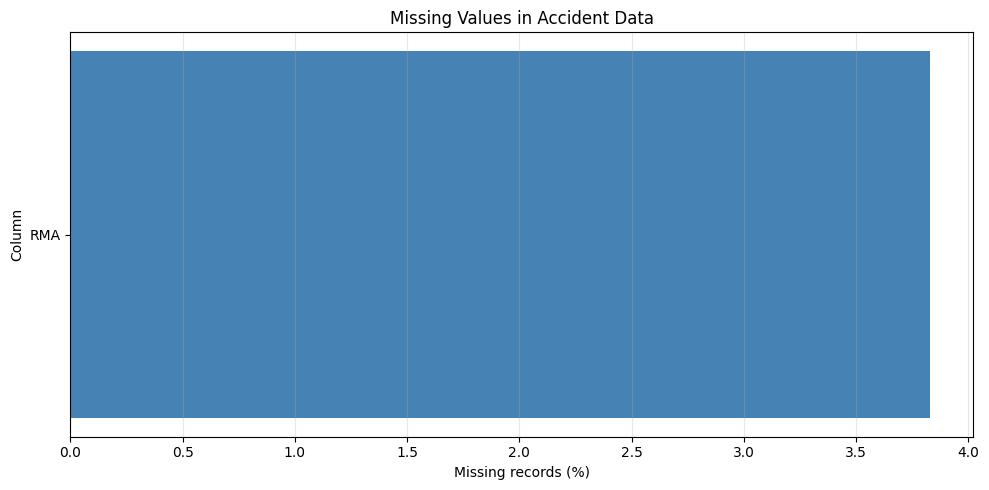

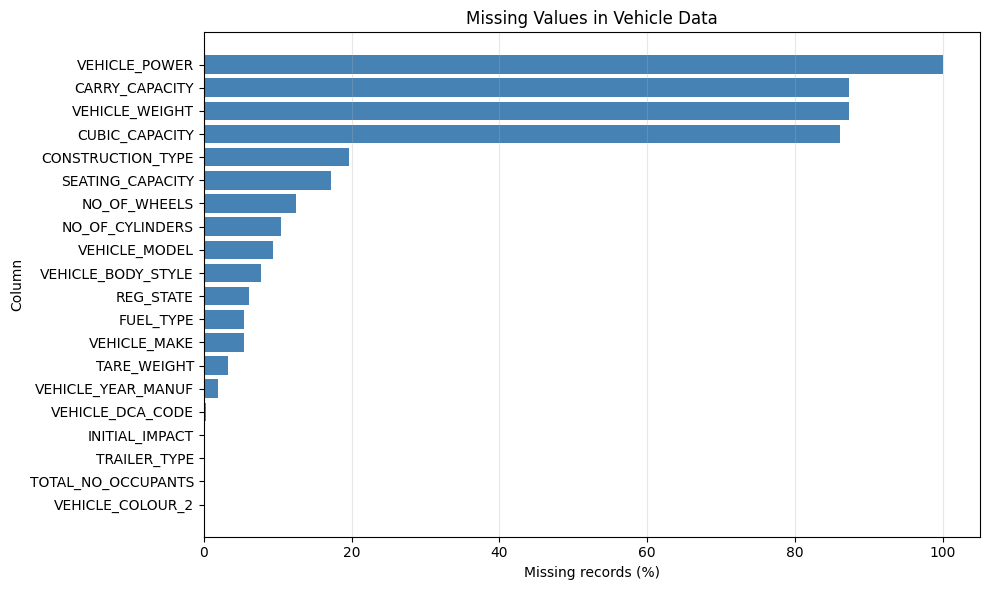

In [12]:
def plot_missing_values(completeness, dataset_name):
    chart_data = completeness[
        completeness["Missing percentage"] > 0
    ].sort_values("Missing percentage")

    if chart_data.empty:
        print(f"No missing values found in {dataset_name}")
        return

    plt.figure(
        figsize=(10, max(5, len(chart_data) * 0.3))
    )

    plt.barh(
        chart_data["Column"],
        chart_data["Missing percentage"],
        color="steelblue"
    )

    plt.title(f"Missing Values in {dataset_name}")
    plt.xlabel("Missing records (%)")
    plt.ylabel("Column")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_missing_values(
    accident_completeness,
    "Accident Data"
)

plot_missing_values(
    vehicle_completeness,
    "Vehicle Data"
)

### 3. Frequencies and data distributions

#### Numerical distribution

In [13]:
def numeric_profile(df):
    numeric_columns = df.select_dtypes(
        include=np.number
    ).columns

    if len(numeric_columns) == 0:
        return pd.DataFrame()

    profile = df[numeric_columns].describe(
        percentiles=[
            0.01, 0.05, 0.25,
            0.50, 0.75, 0.95, 0.99
        ]
    ).T

    profile["missing"] = df[numeric_columns].isna().sum()
    profile["unique"] = df[numeric_columns].nunique()
    profile["zero_values"] = (
        df[numeric_columns] == 0
    ).sum()
    profile["negative_values"] = (
        df[numeric_columns] < 0
    ).sum()

    return profile


accident_numeric = numeric_profile(AccidentDf)
vehicle_numeric = numeric_profile(VehicleDf)

print("Accident numerical profile")
display(accident_numeric)

print("Vehicle numerical profile")
display(vehicle_numeric)

Accident numerical profile


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing,unique,zero_values,negative_values
ACCIDENT_TYPE,200352.0,2.161985,1.939876,1.0,1.0,1.0,1.0,1.0,4.0,6.00,8.00,9.0,0,9,0,0
DAY_OF_WEEK,200352.0,3.897600,1.991365,0.0,0.0,1.0,2.0,4.0,6.0,7.00,7.00,7.0,0,8,4635,0
DCA_CODE,200352.0,138.696140,25.947547,100.0,100.0,102.0,120.0,130.0,167.0,181.00,190.00,199.0,0,81,0,0
LIGHT_CONDITION,200352.0,1.882427,1.678852,1.0,1.0,1.0,1.0,1.0,2.0,5.00,9.00,9.0,0,7,0,0
NODE_ID,200352.0,356910.366590,287899.295054,-10.0,650.0,29821.0,51953.0,294079.5,678216.5,814220.45,824818.47,828456.0,0,143811,0,85
NO_OF_VEHICLES,200352.0,1.824145,0.744475,0.0,1.0,1.0,1.0,2.0,2.0,3.00,4.00,21.0,0,17,6,0
NO_PERSONS_KILLED,200352.0,0.017998,0.144564,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1.00,5.0,0,6,197000,0
NO_PERSONS_INJ_2,200352.0,0.417715,0.624342,0.0,0.0,0.0,0.0,0.0,1.0,1.00,2.00,15.0,0,13,127348,0
NO_PERSONS_INJ_3,200352.0,0.864149,0.786496,0.0,0.0,0.0,0.0,1.0,1.0,2.00,3.00,43.0,0,23,60745,0
NO_PERSONS_NOT_INJ,200352.0,1.034689,1.224403,0.0,0.0,0.0,0.0,1.0,1.0,3.00,5.00,94.0,0,40,65654,0


Vehicle numerical profile


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing,unique,zero_values,negative_values
VEHICLE_YEAR_MANUF,358519.0,1833.643461,566.285656,0.0,0.0,0.0,2002.0,2008.0,2014.0,2020.0,2023.0,3001.0,6951,109,31211,0
VEHICLE_DCA_CODE,364538.0,2.010663,1.972576,1.0,1.0,1.0,1.0,1.0,2.0,8.0,8.0,8.0,932,4,0,0
ROAD_SURFACE_TYPE,365469.0,1.147312,0.828334,1.0,1.0,1.0,1.0,1.0,1.0,2.0,3.0,9.0,1,4,0,0
VEHICLE_POWER,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,365470,0,0,0
VEHICLE_TYPE,365470.0,7.711229,18.325724,1.0,1.0,1.0,1.0,2.0,4.0,61.0,99.0,99.0,0,29,0,0
VEHICLE_WEIGHT,46549.0,5579.683860,7294.726793,251.0,1300.0,1690.0,2490.0,2850.0,3300.0,24000.0,30000.0,340000.0,318921,1344,0,0
NO_OF_WHEELS,319613.0,3.897823,0.682718,1.0,2.0,2.0,4.0,4.0,4.0,4.0,6.0,46.0,45857,15,0,0
NO_OF_CYLINDERS,327242.0,4.464800,1.356281,1.0,1.0,2.0,4.0,4.0,6.0,6.0,8.0,93.0,38228,29,0,0
SEATING_CAPACITY,302392.0,5.041760,2.932775,1.0,2.0,2.0,5.0,5.0,5.0,7.0,8.0,74.0,63078,63,0,0
TARE_WEIGHT,353503.0,1553.250046,1700.990215,0.0,0.0,0.0,1100.0,1400.0,1684.0,2435.0,10380.0,96000.0,11967,4091,51932,0


#### Frequency profile for every column

In [14]:
def frequency_summary(df):
    results = []

    for column in df.columns:
        counts = df[column].value_counts(
            dropna=False
        )

        most_frequent = (
            counts.index[0] if len(counts) > 0 else None
        )

        frequency = (
            counts.iloc[0] if len(counts) > 0 else 0
        )

        results.append({
            "Column": column,
            "Unique values": df[column].nunique(
                dropna=True
            ),
            "Most frequent value": most_frequent,
            "Frequency": frequency,
            "Frequency percentage": round(
                frequency / len(df) * 100,
                2
            )
        })

    return pd.DataFrame(results)


print("Accident frequency summary")
display(frequency_summary(AccidentDf))

print("Vehicle frequency summary")
display(frequency_summary(VehicleDf))

Accident frequency summary


,Column,Unique values,Most frequent value,Frequency,Frequency percentage
0,ACCIDENT_NO,200352,T20120002354,1,0.00
1,ACCIDENT_DATE,5114,2015-04-17,80,0.04
2,ACCIDENT_TIME,1440,16:00:00,2874,1.43
3,ACCIDENT_TYPE,9,1,130521,65.15
4,ACCIDENT_TYPE_DESC,9,Collision with vehicle,130521,65.15
5,DAY_OF_WEEK,8,5,30601,15.27
6,DAY_WEEK_DESC,7,Friday,31530,15.74
7,DCA_CODE,81,130,36174,18.06
8,DCA_DESC,81,REAR END(VEHICLES IN SAME LANE),36174,18.06
9,LIGHT_CONDITION,7,1,134337,67.05


Vehicle frequency summary


,Column,Unique values,Most frequent value,Frequency,Frequency percentage
0,ACCIDENT_NO,200343,T20160000627,21,0.01
1,VEHICLE_ID,21,A,199409,54.56
2,VEHICLE_YEAR_MANUF,109,0.0,31211,8.54
3,VEHICLE_DCA_CODE,4,1.0,199709,54.64
4,INITIAL_DIRECTION,9,S,57279,15.67
5,ROAD_SURFACE_TYPE,4,1.0,347047,94.96
6,ROAD_SURFACE_TYPE_DESC,4,Paved,347047,94.96
7,REG_STATE,11,V,325056,88.94
8,VEHICLE_BODY_STYLE,118,SEDAN,150847,41.27
9,VEHICLE_MAKE,687,TOYOTA,61000,16.69


### Examine categorical values

In [15]:
def examine_category(df, column, top_n=25):
    if column not in df.columns:
        print(f"{column} was not found.")
        return

    counts = df[column].value_counts(
        dropna=False
    ).head(top_n)

    percentages = (
        df[column]
        .value_counts(dropna=False, normalize=True)
        .head(top_n)
        .mul(100)
        .round(2)
    )

    table = pd.DataFrame({
        "Frequency": counts,
        "Percentage": percentages
    })

    display(table)

    counts.sort_values().plot(
        kind="barh",
        figsize=(10, 6),
        color="darkorange"
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel("Number of records")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

### 4. Formats and consistency

#### Text-format inconsistencies


In [16]:
def text_consistency_profile(df):
    results = []

    text_columns = df.select_dtypes(
        include=["object", "string"]
    ).columns

    for column in text_columns:
        original = df[column].astype("string")
        stripped = original.str.strip()
        standardised = stripped.str.upper()

        results.append({
            "Column": column,
            "Original unique values":
                original.nunique(dropna=True),
            "Unique after standardisation":
                standardised.nunique(dropna=True),
            "Possible inconsistent formats":
                original.nunique(dropna=True)
                - standardised.nunique(dropna=True),
            "Values with extra spaces": int(
                (
                    original.notna()
                    & original.ne(stripped)
                ).sum()
            )
        })

    return pd.DataFrame(results).sort_values(
        "Possible inconsistent formats",
        ascending=False
    )


print("Accident text consistency")
display(text_consistency_profile(AccidentDf))

print("Vehicle text consistency")
display(text_consistency_profile(VehicleDf))

Accident text consistency


,Column,Original unique values,Unique after standardisation,Possible inconsistent formats,Values with extra spaces
0,ACCIDENT_NO,200352,200352,0,0
1,ACCIDENT_DATE,5114,5114,0,0
2,ACCIDENT_TIME,1440,1440,0,0
3,ACCIDENT_TYPE_DESC,9,9,0,0
4,DAY_WEEK_DESC,7,7,0,0
5,DCA_DESC,81,81,0,0
6,ROAD_GEOMETRY_DESC,9,9,0,0
7,RMA,6,6,0,0


Vehicle text consistency


,Column,Original unique values,Unique after standardisation,Possible inconsistent formats,Values with extra spaces
0,ACCIDENT_NO,200343,200343,0,0
9,CONSTRUCTION_TYPE,3,3,0,0
15,INITIAL_IMPACT,18,18,0,0
14,VEHICLE_COLOUR_2,17,17,0,0
13,VEHICLE_COLOUR_1,18,18,0,0
12,TRAILER_TYPE,12,12,0,0
11,FINAL_DIRECTION,9,9,0,0
10,FUEL_TYPE,8,8,0,0
8,VEHICLE_TYPE_DESC,29,29,0,0
1,VEHICLE_ID,21,21,0,0


#### Numeric data incorrectly stored as text

In [17]:
def numeric_stored_as_text(df):
    results = []

    text_columns = df.select_dtypes(
        include=["object", "string"]
    ).columns

    for column in text_columns:
        text = (
            df[column]
            .astype("string")
            .str.strip()
            .str.replace(",", "", regex=False)
        )

        non_empty = text.notna() & text.ne("")

        converted = pd.to_numeric(
            text,
            errors="coerce"
        )

        numeric_text_count = (
            converted.notna() & non_empty
        ).sum()

        results.append({
            "Column": column,
            "Non-empty values": int(non_empty.sum()),
            "Values convertible to numbers":
                int(numeric_text_count),
            "Convertible percentage": round(
                numeric_text_count
                / max(non_empty.sum(), 1)
                * 100,
                2
            )
        })

    return pd.DataFrame(results).sort_values(
        "Convertible percentage",
        ascending=False
    )


display(numeric_stored_as_text(AccidentDf))
display(numeric_stored_as_text(VehicleDf))

,Column,Non-empty values,Values convertible to numbers,Convertible percentage
0,ACCIDENT_NO,200352,0,0.0
1,ACCIDENT_DATE,200352,0,0.0
2,ACCIDENT_TIME,200352,0,0.0
3,ACCIDENT_TYPE_DESC,200352,0,0.0
4,DAY_WEEK_DESC,200352,0,0.0
5,DCA_DESC,200352,0,0.0
6,ROAD_GEOMETRY_DESC,200352,0,0.0
7,RMA,192675,0,0.0


,Column,Non-empty values,Values convertible to numbers,Convertible percentage
15,INITIAL_IMPACT,365222,163195,44.68
7,VEHICLE_MODEL,331373,14517,4.38
0,ACCIDENT_NO,365470,0,0.00
9,CONSTRUCTION_TYPE,293465,0,0.00
14,VEHICLE_COLOUR_2,365446,0,0.00
13,VEHICLE_COLOUR_1,365470,0,0.00
12,TRAILER_TYPE,365439,0,0.00
11,FINAL_DIRECTION,365469,0,0.00
10,FUEL_TYPE,345356,0,0.00
8,VEHICLE_TYPE_DESC,365470,0,0.00


### 5. Outliers

#### IQR outlier profile


In [18]:
def outlier_profile(df):
    results = []

    for column in df.select_dtypes(
        include=np.number
    ).columns:

        values = df[column].dropna()

        if values.empty:
            continue

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1

        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr

        outlier_mask = (
            (values < lower_limit)
            | (values > upper_limit)
        )

        results.append({
            "Column": column,
            "Minimum": values.min(),
            "Q1": q1,
            "Median": values.median(),
            "Q3": q3,
            "Maximum": values.max(),
            "IQR lower limit": lower_limit,
            "IQR upper limit": upper_limit,
            "Potential outliers": int(
                outlier_mask.sum()
            ),
            "Outlier percentage": round(
                outlier_mask.mean() * 100,
                2
            )
        })

    return pd.DataFrame(results).sort_values(
        "Potential outliers",
        ascending=False
    )


accident_outliers = outlier_profile(AccidentDf)
vehicle_outliers = outlier_profile(VehicleDf)

display(accident_outliers)
display(vehicle_outliers)

,Column,Minimum,Q1,Median,Q3,Maximum,IQR lower limit,IQR upper limit,Potential outliers,Outlier percentage
3,LIGHT_CONDITION,1,1.0,1.0,2.0,9,-0.50,3.50,18737,9.35
9,NO_PERSONS_NOT_INJ,0,0.0,1.0,1.0,94,-1.50,2.50,16144,8.06
14,SPEED_ZONE,30,60.0,60.0,80.0,999,30.00,110.00,14955,7.46
10,NO_PERSONS,1,2.0,2.0,3.0,97,0.50,4.50,12818,6.40
8,NO_PERSONS_INJ_3,0,0.0,1.0,1.0,43,-1.50,2.50,5926,2.96
5,NO_OF_VEHICLES,0,1.0,2.0,2.0,21,-0.50,3.50,5390,2.69
6,NO_PERSONS_KILLED,0,0.0,0.0,0.0,5,0.00,0.00,3352,1.67
7,NO_PERSONS_INJ_2,0,0.0,0.0,1.0,15,-1.50,2.50,1723,0.86
11,POLICE_ATTEND,1,1.0,1.0,2.0,9,-0.50,3.50,731,0.36
0,ACCIDENT_TYPE,1,1.0,1.0,4.0,9,-3.50,8.50,217,0.11


,Column,Minimum,Q1,Median,Q3,Maximum,IQR lower limit,IQR upper limit,Potential outliers,Outlier percentage
9,TOTAL_NO_OCCUPANTS,0.0,1.0,1.0,1.0,96.0,1.0,1.0,76181,20.85
12,DRIVER_INTENT,1.0,1.0,1.0,3.0,99.0,-2.0,6.0,74819,20.47
3,VEHICLE_TYPE,1.0,1.0,2.0,4.0,99.0,-3.5,8.5,74335,20.34
18,TRAFFIC_CONTROL,0.0,0.0,0.0,1.0,99.0,-1.5,2.5,69909,19.13
8,TARE_WEIGHT,0.0,1100.0,1400.0,1684.0,96000.0,224.0,2560.0,69432,19.64
7,SEATING_CAPACITY,1.0,5.0,5.0,5.0,74.0,5.0,5.0,66608,22.03
15,LAMPS,0.0,2.0,2.0,2.0,9.0,2.0,2.0,65509,17.92
1,VEHICLE_DCA_CODE,1.0,1.0,1.0,2.0,8.0,-0.5,3.5,33839,9.28
5,NO_OF_WHEELS,1.0,4.0,4.0,4.0,46.0,4.0,4.0,32830,10.27
0,VEHICLE_YEAR_MANUF,0.0,2002.0,2008.0,2014.0,3001.0,1984.0,2032.0,32821,9.15


### Boxplot for selected numerical fields

In [19]:
def make_boxplot(df, column, dataset_name):
    if column not in df.columns:
        print(f"{column} was not found.")
        return

    numeric_values = pd.to_numeric(
        df[column],
        errors="coerce"
    )

    plt.figure(figsize=(10, 3))

    sns.boxplot(
        x=numeric_values,
        color="lightblue"
    )

    plt.title(f"{column} Distribution – {dataset_name}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()


# Replace with actual numerical columns.
# make_boxplot(accident, "TOTAL_PERSONS", "Accident")
# make_boxplot(vehicle, "TOTAL_NO_OCCUPANTS", "Vehicle")
# make_boxplot(vehicle, "MANUFACTURE_YEAR", "Vehicle")

### 6. Accuracy and business-rule validation

#### Check negative values

In [20]:
def negative_value_profile(df):
    results = []

    for column in df.columns:
        numeric = pd.to_numeric(
            df[column],
            errors="coerce"
        )

        negative_count = (numeric < 0).sum()

        if negative_count > 0:
            results.append({
                "Column": column,
                "Negative values": int(negative_count),
                "Minimum value": numeric.min()
            })

    return pd.DataFrame(results)


print("Negative values in Accident data")
display(negative_value_profile(AccidentDf))

print("Negative values in Vehicle data")
display(negative_value_profile(VehicleDf))

Negative values in Accident data


,Column,Negative values,Minimum value
0,NODE_ID,85,-10


Negative values in Vehicle data


""


### Dates and times

In [21]:
ACCIDENT_DATE_COLUMN = "ACCIDENT_DATE"
ACCIDENT_TIME_COLUMN = "ACCIDENT_TIME"

if ACCIDENT_DATE_COLUMN in AccidentDf.columns:
    original_dates = AccidentDf[ACCIDENT_DATE_COLUMN]

    parsed_dates = pd.to_datetime(
        original_dates,
        errors="coerce",
        dayfirst=True
    )

    invalid_dates = (
        original_dates.notna()
        & parsed_dates.isna()
    )

    print("Invalid accident dates:", invalid_dates.sum())
    print("Earliest date:", parsed_dates.min())
    print("Latest date:", parsed_dates.max())

    display(
        AccidentDf.loc[
            invalid_dates,
            [ACCIDENT_DATE_COLUMN]
        ].head(20)
    )

if ACCIDENT_TIME_COLUMN in AccidentDf.columns:
    time_text = (
        AccidentDf[ACCIDENT_TIME_COLUMN]
        .astype("string")
        .str.strip()
    )

    valid_time_format = time_text.str.match(
        r"^([01]\d|2[0-3]):[0-5]\d(:[0-5]\d)?$",
        na=False
    )

    invalid_times = (
        time_text.notna()
        & time_text.ne("")
        & ~valid_time_format
    )

    print("Potential invalid times:", invalid_times.sum())

    display(
        AccidentDf.loc[
            invalid_times,
            [ACCIDENT_TIME_COLUMN]
        ].head(20)
    )

C:\Users\prish\AppData\Local\Temp\ipykernel_13660\4194816989.py:7: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  parsed_dates = pd.to_datetime(


Invalid accident dates: 0
Earliest date: 2012-01-01 00:00:00
Latest date: 2025-12-31 00:00:00


,ACCIDENT_DATE


Potential invalid times: 0


,ACCIDENT_TIME


In [ ]:
AccidentDf.to_csv("accidentcleaned.csv")
VehicleDf.to_csv("vehiclecleaned.csv")